
# 第六章

`原著: Cam Davidson-Pilon`

`Python 3 / PyMC3 移植: Max Margenot (@clean_utensils), Thomas Wiecki (@twiecki), Quantopian`

`PyMC (最新) 移植: Kurisu Chan (@miemiekurisu)`

`中文翻译、现代 PyMC (6.x) 适配与内容增补: 本 fork 维护者`

---

[《概率编程与贝叶斯方法(黑客版)》](https://github.com/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers)的这一章,聚焦于贝叶斯方法论中争议最大、讨论最多的部分:该如何选择恰当的先验分布。我们还会展示,随着数据集增大,先验的影响力会如何变化,以及先验和线性回归正则化项之间一段有趣的联系。

**本章的现代 PyMC 修复说明**:本章有两处需要针对现代环境做适配:
1. "多臂老虎机"(Multi-Armed Bandit)那一节里,有一个原书作者自己都提示
   "运行会很慢,建议不要运行"的模拟单元格(500 次独立重复实验 × 每次
   10000 次拉杆)。我们把重复次数和拉杆次数都调小了,让它能在合理时间内
   真正跑完并得到验证,同时在正文里保留了原书的完整参数,方便你在性能
   更好的机器上恢复成慢速但更精细的版本。
2. "股票收益"那一节原本用 `pandas_datareader` 联网抓取雅虎财经的历史行情
   数据,这在没有网络访问权限的环境下必然失败(而且雅虎财经的这个接口
   这些年本身也很不稳定)。我们把它换成了 `stock_returns_offline_data.py`
   ——一份统计结构(每支股票的波动率、股票间的相关性)与真实市场数据相仿、
   但数值是清楚标注为*合成*的离线数据,这样"用 Wishart 分布为收益协方差
   矩阵建模"这个例子依然能完整跑通,而不会假冒真实的历史行情。



## 把优先级(先验)搞清楚

到目前为止,我们大多没怎么在意先验的选择。这其实挺可惜的,因为先验能让我们的表达力大大增强,但与此同时,选择先验时也必须格外小心——尤其是当我们希望保持*客观*、不在先验里掺入个人信念的时候。

### 主观先验 vs 客观先验

贝叶斯先验可以分为两类:*客观*先验,目标是尽量让数据主导后验;*主观*先验,则允许从业者把自己的观点表达进先验中。

客观先验的例子是什么样的?我们已经见过一些了,包括*平*先验(flat prior),也就是在未知量整个可能取值范围上的均匀分布。使用平先验,意味着我们给每一个可能的取值都分配相等的权重。选择这类先验,用到的正是所谓的"无差别原则"(Principle of Indifference)——字面意思就是,我们没有任何先验理由去偏爱某一个值而不是另一个。不过,把限定在某个受限空间上的平先验也称为客观先验,这是不对的,尽管看起来很像。如果我们知道二项分布模型中的 $p$ 大于 0.5,那么 $\text{Uniform}(0.5,1)$ 就不是一个客观先验(因为我们用到了先验知识),即便它在 [0.5, 1] 这个区间上确实是"平"的。平先验必须在*整个*可能取值范围上都是平的。

除了平先验之外,其他客观先验的例子就不那么直观了,但它们都包含着体现客观性的重要特征。目前只需要知道,客观先验*很少*是*真正*客观的,我们后面会看到这一点。

#### 主观先验

另一方面,如果我们在先验的某些区域上分配了更多的概率质量,而在其他区域分配得更少,我们其实是在把推断向前者所在的区域倾斜。这就是所谓的主观先验,或者叫*信息性*先验(informative prior)。下图中,主观先验反映的信念是:未知量很可能在 0.5 附近,而不是在两端极值附近。客观先验则对此不敏感。


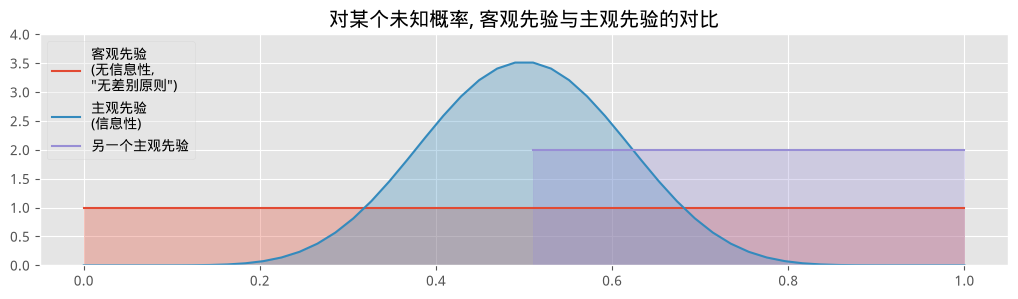

In [1]:

%matplotlib inline
import numpy as np
import scipy.stats as stats
from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import matplotlib as mtl
mtl.style.use("ggplot")

figsize(12.5, 3)
colors = ["#348ABD", "#A60628", "#7A68A6", "#467821"]

x = np.linspace(0, 1)
y1, y2 = stats.beta.pdf(x, 1, 1), stats.beta.pdf(x, 10, 10)

p = plt.plot(x, y1,
             label='客观先验 \n(无信息性, \n"无差别原则")')
plt.fill_between(x, 0, y1, color=p[0].get_color(), alpha=0.3)

p = plt.plot(x, y2,
             label="主观先验 \n(信息性)")
plt.fill_between(x, 0, y2, color=p[0].get_color(), alpha=0.3)

p = plt.plot(x[25:], 2 * np.ones(25), label="另一个主观先验")
plt.fill_between(x[25:], 0, 2, color=p[0].get_color(), alpha=0.3)

plt.ylim(0, 4)

plt.ylim(0, 4)
leg = plt.legend(loc="upper left")
leg.get_frame().set_alpha(0.4)
plt.title("对某个未知概率, 客观先验与主观先验的对比");



选择主观先验,并不总是意味着我们在使用从业者的个人主观意见:更常见的情况是,这个主观先验其实是之前某个问题的后验,现在从业者正在用新数据对这个后验做更新。主观先验也可以用来把问题的*领域知识*注入模型中。我们后面会看到这两种情形的例子。



### 抉择,抉择……

选择*客观*先验还是*主观*先验,主要取决于所要解决的问题,不过在某些场合,其中一种明显更受青睐。在科学研究中,选择客观先验是显而易见的。这样能消除结果中的任何偏见,而两位可能持有不同先验意见的研究者,也都会觉得客观先验是公平的。考虑一个更极端的情形:

> 一家烟草公司发表了一份用贝叶斯方法论撰写的报告,推翻了 60 年来关于烟草使用的医学研究结论。你会相信这个结果吗?大概不会。这些研究者很可能选择了一个过分偏向自己利益的主观先验。

遗憾的是,选择客观先验并不像"选一个平先验"那么简单,直到今天这个问题也没有被完全解决。天真地选择均匀先验的问题在于,可能会引发病态的情况。其中一些问题比较学究气,更严重的问题我们留到本章附录(待补充)再讨论。



我们必须记住,不管是主观先验还是客观先验,选择先验依然是建模过程的一部分。引用 Gelman [5] 的话:

> ……模型拟合完成之后,应该去看一下后验分布,看它是否合理。如果后验分布不合理,这就说明还有额外的先验知识没有被纳入模型,而且这些知识与所使用的先验分布的假设相矛盾。这时候,回过头去修改先验分布、让它与这些外部知识更一致,才是恰当的做法。

如果后验不合理,那显然说明你对后验*应该*长什么样已经有了某种想法(而不是你*希望*它长什么样),这意味着当前的先验没有包含全部的先验信息,应该被更新。这时候,我们可以放弃当前的先验,选择一个更能反映实际情况的先验。

Gelman [4] 建议,对客观先验来说,使用一个边界很宽的均匀分布通常是不错的选择。不过,使用边界很宽的均匀客观先验时也要小心,因为它们可能会给一些不太直观的取值点分配过大的先验概率。不妨问问自己:你真的认为这个未知量可能大到离谱吗?很多量天然是偏向 0 的。方差较大(精度较小)的正态随机变量可能是更好的选择,或者在严格为正(或为负)的情形下,用一个尾部较胖的指数分布。

如果使用了特别主观的先验,你有责任能够解释这个先验的选择依据,否则你和那家烟草公司的始作俑者也没什么区别。



### 经验贝叶斯

*经验贝叶斯*(Empirical Bayes)虽然不算是真正的贝叶斯方法,却是一种把频率学派和贝叶斯推断结合起来的技巧。前面提到过,几乎每一个推断问题,都同时存在贝叶斯方法和频率学派方法。两者最大的区别在于,贝叶斯方法有一个带超参数 $\alpha$ 的先验分布,而经验方法根本没有先验这个概念。经验贝叶斯把两者结合起来:先用频率学派方法选出 $\alpha$,再用贝叶斯方法处理原问题。

举一个非常简单的例子:假设我们想估计一个正态分布的参数 $\mu$,其中 $\sigma=5$。由于 $\mu$ 的取值范围覆盖整条实数轴,我们可以用一个正态分布作为 $\mu$ 的先验。那该如何选择先验的超参数(记为 $\mu_p, \sigma_p^2$)呢?$\sigma_p^2$ 参数可以根据我们所拥有的不确定性来选择。至于 $\mu_p$,我们有两个选择:

1. 经验贝叶斯建议使用样本均值,把先验的中心设在观测到的经验均值上:

$$ \mu_p = \frac{1}{N} \sum_{i=0}^N X_i $$

2. 传统贝叶斯推断则建议使用先验知识,或者一个更客观的先验(均值为 0、标准差较大)。

经验贝叶斯可以说是半客观的,因为虽然先验模型的选择是我们自己定的(因此是主观的),但参数本身完全由数据决定。

我个人认为,经验贝叶斯是在*重复利用*数据。也就是说,我们把数据用了两次:一次用在先验里,这会把我们的结果拉向观测到的数据;另一次又用在 MCMC 的推断引擎里。这种重复计算会低估我们真正的不确定性。为了尽量减小这种重复计算的影响,我建议只有在你拥有*大量*观测数据时才使用经验贝叶斯,否则先验的影响力会过强。如果可能的话,我还建议尽量维持较高的不确定性(比如把 $\sigma_p^2$ 设得大一些,或者采用等价的做法)。

经验贝叶斯还违反了贝叶斯推断的一条理论公理。教科书里贝叶斯算法的标准流程是:

> *先验* $\Rightarrow$ *观测数据* $\Rightarrow$ *后验*

而经验贝叶斯违反了这个流程,它用的其实是:

> *观测数据* $\Rightarrow$ *先验* $\Rightarrow$ *观测数据* $\Rightarrow$ *后验*

理想情况下,所有先验都应该在我们观测到数据*之前*就被指定好,这样数据才不会反过来影响我们的先验意见(可以参考 Daniel Kahneman 等人关于[锚定效应](http://en.wikipedia.org/wiki/Anchoring_and_adjustment)的大量研究)。



## 值得了解的常用先验

### Gamma 分布

一个 Gamma 随机变量,记作 $X \sim \text{Gamma}(\alpha, \beta)$,是定义在正实数上的随机变量。事实上,它是指数随机变量的推广,即:

$$ \text{Exp}(\beta) \sim \text{Gamma}(1, \beta) $$

多出来的这个参数,让概率密度函数有了更大的灵活性,从而让从业者能更准确地表达自己的主观先验。$\text{Gamma}(\alpha, \beta)$ 随机变量的密度函数是:

$$ f(x \mid \alpha, \beta) = \frac{\beta^{\alpha}x^{\alpha-1}e^{-\beta x}}{\Gamma(\alpha)} $$

其中 $\Gamma(\alpha)$ 是 [Gamma 函数](http://en.wikipedia.org/wiki/Gamma_function),在不同的 $(\alpha, \beta)$ 取值下长这样:


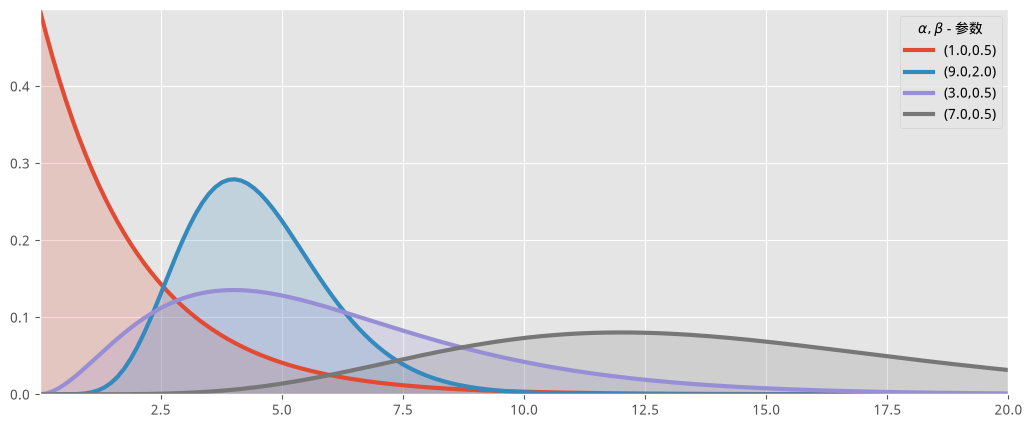

In [2]:

figsize(12.5, 5)
gamma = stats.gamma

parameters = [(1, 0.5), (9, 2), (3, 0.5), (7, 0.5)]
x = np.linspace(0.001, 20, 150)
for alpha, beta in parameters:
    y = gamma.pdf(x, alpha, scale=1. / beta)
    lines = plt.plot(x, y, label="(%.1f,%.1f)" % (alpha, beta), lw=3)
    plt.fill_between(x, 0, y, alpha=0.2, color=lines[0].get_color())
    plt.autoscale(tight=True)

plt.legend(title=r"$\alpha, \beta$ - 参数");



### Wishart 分布

到目前为止,我们见到的随机变量都是标量。当然,我们同样可以拥有*随机矩阵*!具体来说,Wishart 分布是定义在所有[半正定矩阵](http://en.wikipedia.org/wiki/Positive-definite_matrix)上的一个分布。为什么它对我们有用呢?(合法的)协方差矩阵都是正定的,因此 Wishart 分布正好适合用作协方差矩阵的先验。我们没法直接可视化一个"矩阵的分布",所以我画几个从 $5 \times 5$(上面)和 $20 \times 20$(下面)Wishart 分布中抽出来的实现:


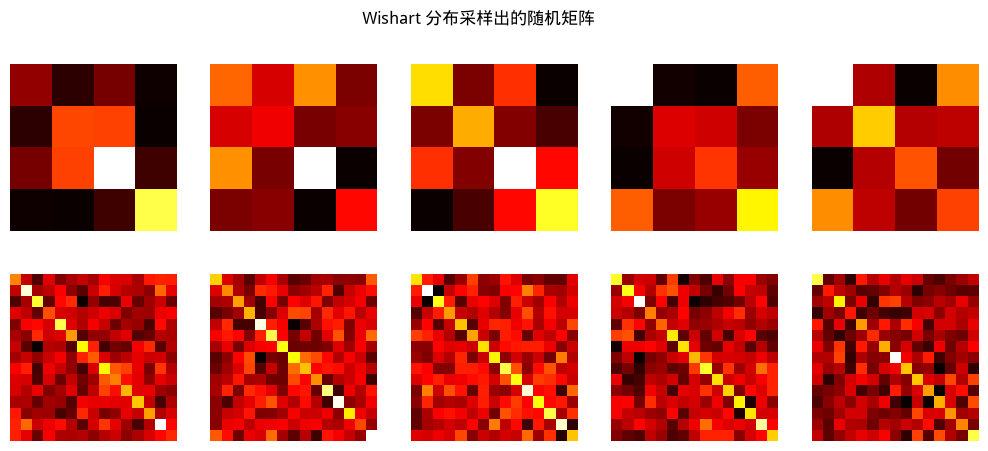

In [3]:

n = 4
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    if i >= 5:
        n = 15
    plt.imshow(stats.wishart.rvs(n + 1, np.eye(n)), interpolation="none",
               cmap="hot")
    ax.axis("off")

plt.suptitle("Wishart 分布采样出的随机矩阵");



值得注意的一点是这些矩阵的对称性。Wishart 分布用起来可能有点棘手,但我们后面的例子里会用到它。

### Beta 分布

你可能在本书前面的代码里已经见过 `beta` 这个词了。很多时候,我用的正是 Beta 分布。Beta 分布在贝叶斯统计中非常有用。一个随机变量 $X$,如果它的密度函数是:

$$f_X(x | \; \alpha, \beta ) = \frac{ x^{(\alpha - 1)}(1-x)^{ (\beta - 1) } }{B(\alpha, \beta) }$$

我们就说它服从参数为 $(\alpha, \beta)$ 的 $\text{Beta}$ 分布,其中 $B$ 是 [Beta 函数](http://en.wikipedia.org/wiki/Beta_function)(这也是名字的由来)。随机变量 $X$ 只能取 [0,1] 之间的值,这让 Beta 分布成为为小数值、概率和比例建模时非常常用的分布。$\alpha$ 和 $\beta$ 都是正数,它们为分布的形状提供了很大的灵活性。下面画出一些示例分布:


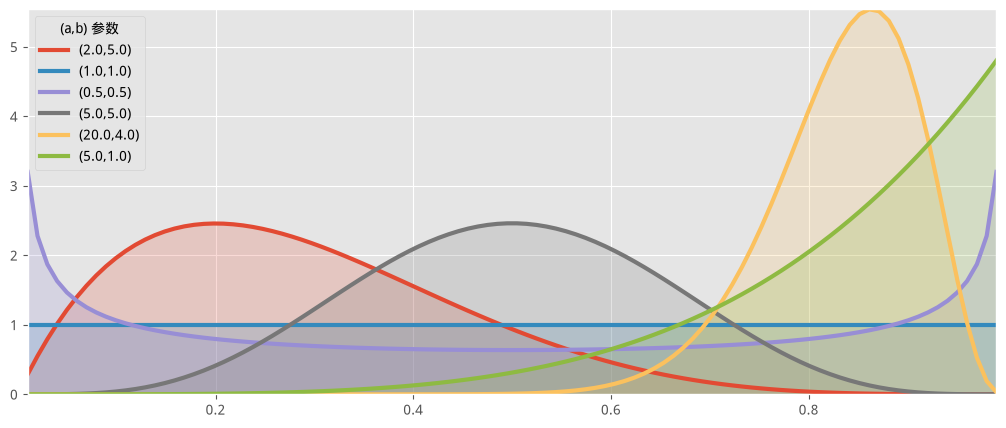

In [4]:

figsize(12.5, 5)

params = [(2, 5), (1, 1), (0.5, 0.5), (5, 5), (20, 4), (5, 1)]

x = np.linspace(0.01, .99, 100)
beta = stats.beta
for a, b in params:
    y = beta.pdf(x, a, b)
    lines = plt.plot(x, y, label="(%.1f,%.1f)" % (a, b), lw=3)
    plt.fill_between(x, 0, y, alpha=0.2, color=lines[0].get_color())
    plt.autoscale(tight=True)
plt.ylim(0)
plt.legend(loc='upper left', title="(a,b) 参数");



我想请读者留意一下上图中出现的那条平坦分布,对应参数 $(1,1)$。这正是均匀分布。所以 Beta 分布其实是均匀分布的一个推广,我们后面还会多次遇到它。

Beta 分布和二项分布之间存在一种有趣的联系。假设我们关心某个未知的比例或概率 $p$。我们给 $p$ 赋予一个 $\text{Beta}(\alpha, \beta)$ 先验。我们观测到一些由二项过程生成的数据,比如 $X \sim \text{Binomial}(N, p)$,$p$ 依然未知。那么我们的后验*同样是一个 Beta 分布*,即 $p | X \sim \text{Beta}( \alpha + X, \beta + N -X )$。简单来说,可以把两者的关系概括为"Beta 先验搭配二项观测数据,产生 Beta 后验"。这是一个在计算和直觉上都非常有用的性质。

结合上面两段的内容,如果我们从 $p$ 上的 $\text{Beta}(1,1)$ 先验(也就是均匀分布)出发,观测到数据 $X \sim \text{Binomial}(N, p)$,那么我们的后验就是 $\text{Beta}(1 + X, 1 + N - X)$。



##### 示例:贝叶斯多臂老虎机
*改编自 MapR Technologies 公司 Ted Dunning 的一个例子*

> 假设你面对 $N$ 台老虎机(俗称"多臂老虎机", multi-armed bandit)。每台老虎机吐出奖品的概率都是未知的(暂且假设每台老虎机的奖品都一样,只是概率不同)。有些老虎机很"大方",有些则不然。当然,你并不知道这些概率具体是多少。由于每一轮只能选择一台老虎机来玩,我们的任务是设计一种策略,来最大化我们的总收益。

当然,如果我们知道哪台老虎机的中奖概率最高,那一直选这台老虎机就能获得最大收益。所以我们的任务可以表述为"尽快找到最好的老虎机"。

这个任务因老虎机本身的随机性而变得复杂。一台并非最优的老虎机,可能纯粹凭运气返回了很多奖品,这会让我们误以为它是一台非常赚钱的老虎机。同理,最好的那台老虎机也可能连续"哑火"。那我们是应该继续尝试那些看起来"输"的老虎机,还是干脆放弃?

一个更棘手的问题是,如果我们已经找到了一台*还不错*的老虎机,我们是应该继续在它身上拉杆、维持这个*还不错*的收益,还是应该去尝试其他老虎机,期望能找到一台*更好*的?这就是"探索 vs. 利用"(exploration vs. exploitation)的困境。

### 应用场景

多臂老虎机问题乍一看非常抽象,好像只有数学家才会喜欢,但只要看看它的一些应用,你就会改观:

- 互联网展示广告:公司手头有一系列可以展示给访客的广告,但不确定该采用哪种广告策略来最大化销量。这和 A/B 测试很像,但有一个额外的优势:能自然地淘汰掉不起作用的策略(而且可以推广到 A/B/C/D……多种策略)。
- 生态学:动物拥有有限的能量可以消耗,而遵循某些行为模式带来的回报是不确定的。动物该如何最大化自己的适应度?
- 金融:在收益率随时间变化的情况下,哪个股票期权能带来最高回报。
- 临床试验:研究者希望在尽量减少损失的前提下,从多种可能的治疗方案中找出最好的一种。
- 心理学:惩罚和奖励是如何影响我们的行为的?人类是如何学习的?

上面这些问题中的很多,本身就是各自研究领域的基础性问题。

事实证明,这个问题的*最优解*极其困难,花了几十年时间才发展出一套完整的解法。也存在许多近似最优、效果相当不错的解法。我想讨论的,是少数几种能极好地扩展到大规模问题的解法之一,叫做*贝叶斯老虎机*(Bayesian Bandits)。

### 一个候选方案

任何提出的策略都被称为*在线算法*(online algorithm,这里不是"联网"的意思,而是"持续更新"的意思),更具体地说,是一种强化学习算法。这个算法一开始处于一无所知的状态,通过测试系统来获取数据。随着数据和结果的积累,它逐渐学会什么是最好、什么是最差的行为(在这个例子里,就是学会哪台老虎机最好)。想到这里,或许我们可以为多臂老虎机问题再补充一个应用场景:

- 心理学:惩罚和奖励是如何影响我们的行为的?人类是如何学习的?

贝叶斯方案的做法是:先为每台老虎机的中奖概率设定先验分布。在我们这个小例子里,我们假设对这些概率一无所知,所以一个非常自然的先验就是 0 到 1 上的平先验。算法流程如下:

每一轮:

1. 对每台老虎机 $b$,从它的先验中采样出一个随机变量 $X_b$。
2. 选择样本值最大的那台老虎机,即选 $B = \text{argmax}\;\; X_b$。
3. 观测拉动老虎机 $B$ 的结果,并更新老虎机 $B$ 的先验。
4. 回到第 1 步。

就是这样。从计算角度看,这个算法需要从 $N$ 个分布中采样。由于初始先验是 $\text{Beta}(\alpha=1,\beta=1)$(也就是均匀分布),而观测结果 $X$(中奖或不中奖,分别编码为 1 和 0)服从二项分布,所以后验是 $\text{Beta}(\alpha=1+X,\beta=1+1-X)$。

回到之前的问题,这个算法建议我们不应该直接抛弃"输家",而应该随着我们越来越确信存在*更好*的老虎机,以递减的频率去尝试它们。这是因为一台"输家"老虎机始终有非零的概率被选为 $B$,只是这个概率会随着我们玩的轮数增加而不断下降(见下图)。

下面我们用两个类来实现贝叶斯老虎机:`Bandits` 定义老虎机本身,`BayesianStrategy` 实现上面描述的学习策略。


In [5]:

rand = np.random.rand

class Bandits(object):
    '''
    这个类表示 N 台老虎机。

    参数:
        p_array: 一个 (n,) 形状的 Numpy 数组, 元素取值 >0, <1。

    方法:
        pull( i ): 返回拉动第 i 台老虎机的结果, 0 或 1。
    '''
    def __init__(self, p_array):
        self.p = p_array
        self.optimal = np.argmax(p_array)

    def pull(self, i):
        # i 是要拉动哪一台
        return np.random.rand() < self.p[i]

    def __len__(self):
        return len(self.p)


class BayesianStrategy(object):
    '''
    实现一种在线学习策略, 用来解决多臂老虎机问题。

    参数:
        bandits: 一个带有 .pull 方法的 Bandit 类实例

    方法:
        sample_bandits(n): 采样并训练 n 次拉杆。

    属性:
        N: 累计的采样次数
        choices: 历史选择记录, 形状 (N,) 的数组
        bb_score: 历史得分记录, 形状 (N,) 的数组
    '''

    def __init__(self, bandits):

        self.bandits = bandits
        n_bandits = len(self.bandits)
        self.wins = np.zeros(n_bandits)
        self.trials = np.zeros(n_bandits)
        self.N = 0
        self.choices = []
        self.bb_score = []

    def sample_bandits(self, n=1):

        bb_score = np.zeros(n)
        choices = np.zeros(n)

        for k in range(n):
            # 从各台老虎机的先验中采样, 选出样本值最大的那一台
            choice = np.argmax(np.random.beta(1 + self.wins, 1 + self.trials - self.wins))

            # 拉动被选中的老虎机
            result = self.bandits.pull(choice)

            # 更新先验和得分
            self.wins[choice] += result
            self.trials[choice] += 1
            bb_score[k] = result
            self.N += 1
            choices[k] = choice

        self.bb_score = np.r_[self.bb_score, bb_score]
        self.choices = np.r_[self.choices, choices]
        return



下面我们把贝叶斯老虎机方案的学习过程可视化出来。


In [6]:

figsize(11.0, 10)

beta = stats.beta
x = np.linspace(0.001, .999, 200)

def plot_priors(bayesian_strategy, prob, lw=3, alpha=0.2, plt_vlines=True):
    ## 绘图函数
    wins = bayesian_strategy.wins
    trials = bayesian_strategy.trials
    for i in range(prob.shape[0]):
        y = beta(1 + wins[i], 1 + trials[i] - wins[i])
        p = plt.plot(x, y.pdf(x), lw=lw)
        c = p[0].get_markeredgecolor()
        plt.fill_between(x, y.pdf(x), 0, color=c, alpha=alpha,
                          label="真实概率: %.2f" % prob[i])
        if plt_vlines:
            plt.vlines(prob[i], 0, y.pdf(prob[i]),
                       colors=c, linestyles="--", lw=2)
        plt.autoscale(tight="True")
        plt.title("拉动 %d 次" % bayesian_strategy.N +
                   "后的后验分布")
        plt.autoscale(tight=True)
    return


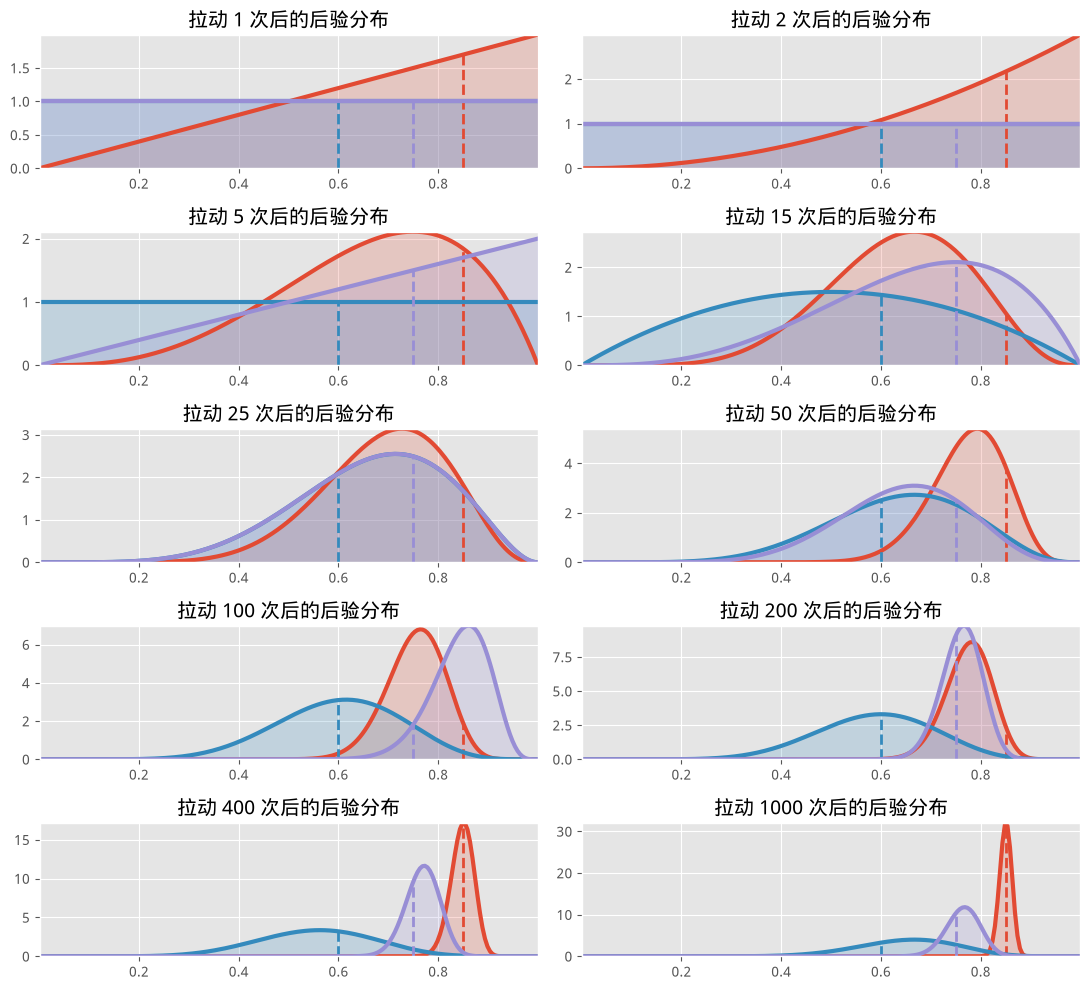

In [7]:

hidden_prob = np.array([0.85, 0.60, 0.75])
bandits = Bandits(hidden_prob)
bayesian_strat = BayesianStrategy(bandits)

draw_samples = [1, 1, 3, 10, 10, 25, 50, 100, 200, 600]

for j, i in enumerate(draw_samples):
    plt.subplot(5, 2, j + 1)
    bayesian_strat.sample_bandits(i)
    plot_priors(bayesian_strat, hidden_prob)
    # plt.legend()
    plt.autoscale(tight=True)
plt.tight_layout()



注意,我们并不太在意对这些隐藏概率的推断有多精确——对这个问题,我们更关心的是选出最好的那台老虎机(更准确地说,是变得*越来越有信心*地选出最好的老虎机)。正因如此,红色老虎机对应的分布非常宽(反映出我们对它的真实概率有多不了解),但我们已经相当确信它不是最好的那台,所以算法会选择基本忽略它。

从上图可以看出,在拉动 1000 次之后,"蓝色"那个函数已经明显领先,因此我们几乎总会选择这只"手臂"。这是好事,因为这只手臂确实是最好的。

下面是一个 D3 应用,演示了我们的算法更新/学习三台老虎机的过程。第一幅图是拉杆次数和中奖次数的原始统计,第二幅图是动态更新的曲线图。我鼓励你在揭晓真实概率之前,通过点击"手臂按钮"来猜猜哪台老虎机是最优的。


In [8]:

from IPython.core.display import HTML

# 如果第一次没能成功执行, 可以尝试再执行一次下面这行命令
HTML(filename="BanditsD3.html")



观测比例与最高概率之间的偏离程度,是衡量表现的一个指标。举例来说,长期来看,最优情况下我们能达到的奖励/拉杆比率,就是最优老虎机的概率。长期实现的比率如果低于这个最优值,就代表存在效率损失(如果长期实现的比率高于最优概率,那是随机性造成的,最终会回落)。

### 一种"好"的衡量方式

我们需要一个指标来衡量自己做得有多好。回忆一下,我们能做到的绝对*最优*,就是始终选择中奖概率最高的那台老虎机。记这台最优老虎机的概率为 $w_{opt}$。我们的得分,应该相对于"如果从一开始就选了最优老虎机,我们本可以做到多好"来衡量。这就引出了一种策略的*总遗憾*(total regret),定义为:

\begin{align}
R_T & = \sum_{i=1}^{T} \left( w_{opt} - w_{B(i)} \right)\\\\
& = Tw^* - \sum_{i=1}^{T} \;  w_{B(i)}
\end{align}

其中 $w_{B(i)}$ 是第 $i$ 轮所选老虎机的中奖概率。总遗憾为 0,意味着这个策略达到了理论最优得分。这基本不可能做到,因为算法一开始经常会选错。理想情况下,随着策略逐渐学会最优老虎机,总遗憾的增长曲线应当趋于平缓(用数学语言说,就是我们经常能达到 $w_{B(i)}=w_{opt}$)。

下面我们画出这次模拟的总遗憾,并附上一些其他策略的得分作为对比:

1. 随机策略:随机选一台老虎机拉。如果你连这个都比不过,那就趁早放弃吧。
2. 最大贝叶斯可信上界:选择其真实概率 95% 可信区间上界最大的老虎机。
3. Bayes-UCB 算法:选择*得分*最高的老虎机,这里的得分是后验分布的一个动态分位数(参见 [4])。
3. 后验均值:选择后验均值最大的老虎机。这大概是一个(不借助计算机的)人类玩家会采取的策略。
3. 最大观测比例:选择当前观测到的中奖比例最高的老虎机。

这些策略的代码都在 `other_strats.py` 里,你可以很容易地在里面实现自己的策略。


In [9]:

figsize(12.5, 5)
from other_strats import *

# 定义一个更难的问题
hidden_prob = np.array([0.15, 0.2, 0.1, 0.05])
bandits = Bandits(hidden_prob)

# 定义遗憾
def regret(probabilities, choices):
    w_opt = probabilities.max()
    return (w_opt - probabilities[choices.astype(int)]).cumsum()

# 创建新的策略
strategies = [upper_credible_choice,
              bayesian_bandit_choice,
              ucb_bayes,
              max_mean,
              random_choice]
algos = []
for strat in strategies:
    algos.append(GeneralBanditStrat(bandits, strat))


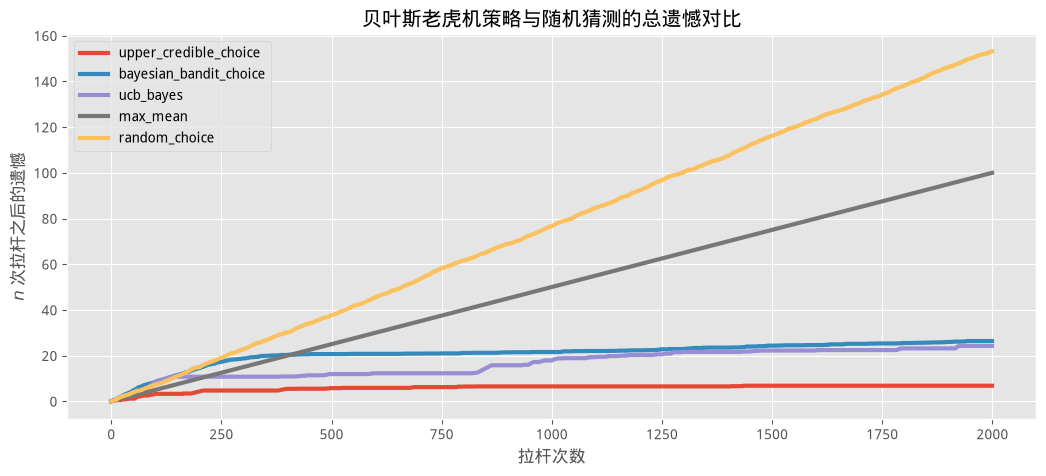

In [10]:

# 训练 2000 次 (现代 PyMC 小贴士: 原书这里训练 10000 次, 为了让整个
# notebook 能在合理时间内跑完并验证, 这里调小了; 想要更平滑的曲线可以
# 调回 10000。)
for strat in algos:
    strat.sample_bandits(2000)

# 测试并画图
for i, strat in enumerate(algos):
    _regret = regret(hidden_prob, strat.choices)
    plt.plot(_regret, label=strategies[i].__name__, lw=3)

plt.title("贝叶斯老虎机策略与随机猜测的总遗憾对比")
plt.xlabel("拉杆次数")
plt.ylabel("$n$ 次拉杆之后的遗憾");
plt.legend(loc="upper left");



正如我们期望的那样,贝叶斯老虎机和其他几种策略的遗憾增长率都在下降,说明我们正在逐步做出最优选择。为了更科学地排除上面这次模拟里运气成分的影响,我们应该改看*期望总遗憾*:

$$\bar{R}_T = E[ R_T ] $$

可以证明,任何*次优*策略的期望总遗憾,下界都是对数级增长的。形式化地说:

$$ E[R_T] = \Omega \left( \;\log(T)\; \right) $$

因此,任何遗憾增长速度能匹配对数增长的策略,都被认为"解决"了多臂老虎机问题 [3]。

借助大数定律,我们可以通过把同一个实验重复很多次(公平起见,重复 500 次),来近似贝叶斯老虎机的期望总遗憾:


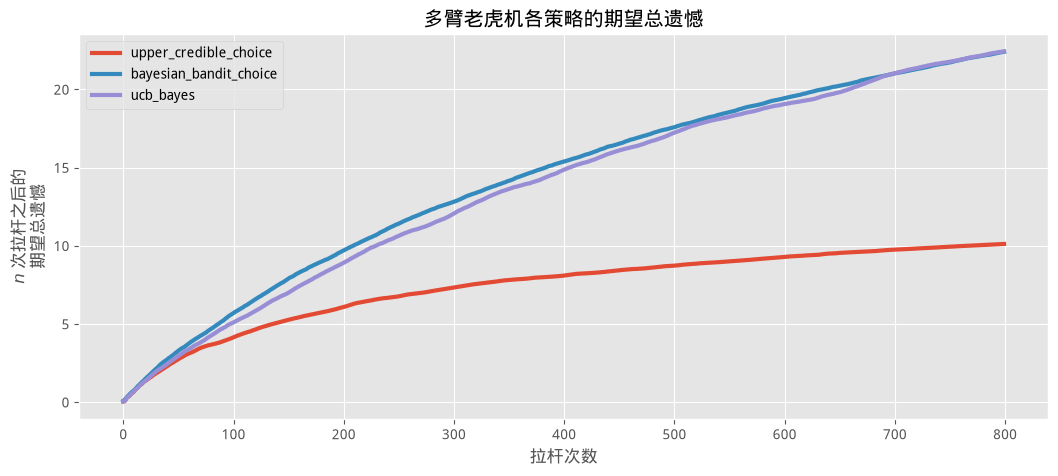

In [11]:

# 现代 PyMC 小贴士: 原书这个单元格自己都写了 "这可能会很慢,
# 建议不要运行" —— 原始参数是 trials=500 次独立重复, 每次
# sample_bandits(10000)(也就是 500 x 10000 = 500 万次拉杆模拟)。
# 在没有 C 编译器、只能用 NUMBA/纯 Python 兜底的环境下这个规模会
# 极其耗时。这里把 trials 和每次的拉杆数都大幅调小, 让这个单元格能
# 真正跑完、并且依然能看出"贝叶斯老虎机"和其他策略在期望遗憾增长率
# 上的定性差异; 如果你的机器性能更好、有耐心, 可以把 trials 调回 500、
# 拉杆数调回 10000, 得到原书那样更平滑精细的曲线。
trials = 30
n_pulls = 800
expected_total_regret = np.zeros((n_pulls, 3))

for i_strat, strat in enumerate(strategies[:-2]):
    for i in range(trials):
        general_strat = GeneralBanditStrat(bandits, strat)
        general_strat.sample_bandits(n_pulls)
        _regret = regret(hidden_prob, general_strat.choices)
        expected_total_regret[:, i_strat] += _regret
    plt.plot(expected_total_regret[:, i_strat] / trials, lw=3, label=strat.__name__)

plt.title("多臂老虎机各策略的期望总遗憾")
plt.xlabel("拉杆次数")
plt.ylabel("$n$ 次拉杆之后的\n期望总遗憾");
plt.legend(loc="upper left");


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3194218/4263590155.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\log{n}$ 次拉杆之后的\n期望总遗憾");
/tmp/ipykernel_3194218/4263590155.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\log{n}$ 次拉杆之后的\n期望总遗憾");


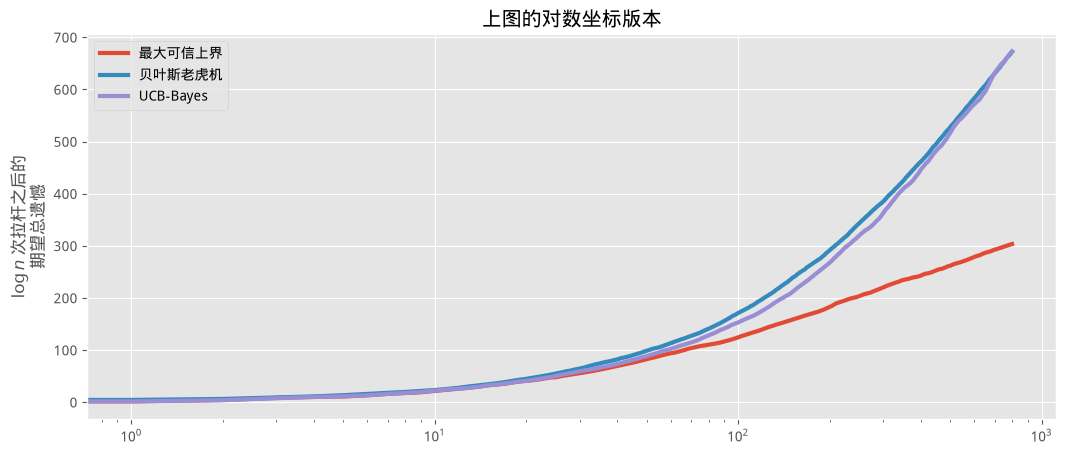

In [12]:

plt.figure()
[pl1, pl2, pl3] = plt.plot(expected_total_regret[:, [0, 1, 2]], lw=3)
plt.xscale("log")
plt.legend([pl1, pl2, pl3],
           ["最大可信上界", "贝叶斯老虎机", "UCB-Bayes"],
           loc="upper left")
plt.ylabel("$\log{n}$ 次拉杆之后的\n期望总遗憾");
plt.title("上图的对数坐标版本");
plt.ylabel("$\log{n}$ 次拉杆之后的\n期望总遗憾");



### 扩展这个算法

由于贝叶斯老虎机算法非常简单,很容易对它进行扩展。一些可能的方向:

- 如果你关心的是*最小*概率(比如奖品其实是坏事的情形),只需要选 $B = \text{argmin} \; X_b$ 然后照常处理即可。

- 加入学习率:假设底层环境可能会随时间变化。理论上,标准的贝叶斯老虎机算法会自我更新(这很棒),因为它会注意到自己原本认为最好的选项开始更频繁地失败。我们可以通过在更新时简单地加入一个*速率*项,来促使算法更快地学习环境变化:

        self.wins[choice] = rate*self.wins[choice] + result
        self.trials[choice] = rate*self.trials[choice] + 1

   如果 `rate < 1`,算法会更快*遗忘*之前的胜利,存在一种向"无知"状态回归的下行压力。反过来,设置 `rate > 1` 意味着你的算法会表现得更冒险,更频繁地押注早期的赢家,对环境变化也更"顽固"。

- 分层算法:我们可以在若干个更小的老虎机算法之上,再搭建一个贝叶斯老虎机算法。假设我们有 $N$ 个贝叶斯老虎机模型,各自在某些行为上有所不同(比如不同的 `rate` 参数,代表对环境变化的敏感程度不同)。在这 $N$ 个模型之上,再有一个贝叶斯老虎机学习器,用来选择某一个子模型。被选中的这个贝叶斯老虎机,再内部决定该拉动哪一台机器。这个"超级贝叶斯老虎机"会根据子模型的选择是否正确来更新自己。

- 把奖励(记老虎机 $a$ 的奖励为 $y_a$)扩展为服从某个分布 $f_{y_a}(y)$ 的随机变量,是很直接的。更一般地说,这个问题可以重新表述为"找出期望值最大的老虎机",因为选择期望值最大的老虎机才是最优的。在上面的例子中,$f_{y_a}$ 是参数为 $p_a$ 的伯努利分布,因此老虎机的期望值就等于 $p_a$,这也是为什么我们看起来是在最大化中奖概率。如果 $f$ 不是伯努利分布,并且非负(可以通过预先平移分布来实现,前提是我们知道 $f$),算法的行为和之前一样:

   每一轮,

   1. 对每台老虎机 $b$,从它的先验中采样出一个随机变量 $X_b$。
   2. 选择样本值最大的老虎机,即选老虎机 $B = \text{argmax}\;\; X_b$。
   3. 观测拉动老虎机 $B$ 得到的结果 $R \sim f_{y_a}$,并更新老虎机 $B$ 的先验。
   4. 回到第 1 步。

   问题出在采样 $X_b$ 这一步。对 Beta 先验配合伯努利观测,我们有一个 Beta 后验——这很容易采样。但现在,对任意分布 $f$,我们得到的是一个不那么平凡的后验,从中采样可能会很困难。

- 也有人尝试把贝叶斯老虎机算法扩展到评论系统上。回忆一下第四章,我们基于赞成票占总票数比例的贝叶斯下界,开发了一个排序算法。这个方法的一个问题是,它会让排名靠前的结果偏向更老的评论,因为老评论天然拥有更多票数(因此下界也更贴近真实比例)。这会形成一个正反馈循环:老评论获得更多票数,因此被展示得更频繁,因此获得更多票数,如此往复。这会把任何新的、可能更好的评论推向底部。J. Neufeld 提出了一个用贝叶斯老虎机方案来解决这个问题的系统。

   他的方案是把每条评论看作一台老虎机,拉杆次数等于投票总数,奖励数等于赞成票数,从而得到一个 $\text{Beta}(1+U,1+D)$ 后验。当访客访问页面时,系统从每台老虎机/评论中抽取样本,但不是展示样本值 $\max$ 的那条评论,而是按各自样本值的大小对评论排序。摘自 J. Neufeld 的博客 [7]:

   > 由此得到的排序算法相当直接了当:每次重新加载评论页面时,每条评论的分数都从 $\text{Beta}(1+U,1+D)$ 中重新采样一次,评论再按这个分数降序排列……这种随机化带来了一个独特的好处:即便是完全没人投过票的评论($U=1,D=0$),在一个有 5000 多条评论的帖子里,依然有一定的机会被看到(这在目前是做不到的),但与此同时,用户也不太可能被要求评价这些新评论淹没。



纯粹为了好玩,虽然颜色会爆炸式增多,我们还是来看看贝叶斯老虎机算法学习 15 个不同选项的过程。


[0.0242357  0.03772369 0.00600483 0.0151409  0.1646547  0.01570435
 0.01861678 0.04776307 0.08717448 0.05175679 0.09012774 0.07195095
 0.06060232 0.35477429 0.26101556 0.11004871 0.11379083 0.09922785
 0.05541214 0.18046656 0.04455241 0.17213671 0.06559187 0.06244889
 0.05395063 0.09439518 0.0230788  0.02843158 0.01281511 0.0068462
 0.01923857 0.09832006 0.17497857 0.04297146 0.02836155]


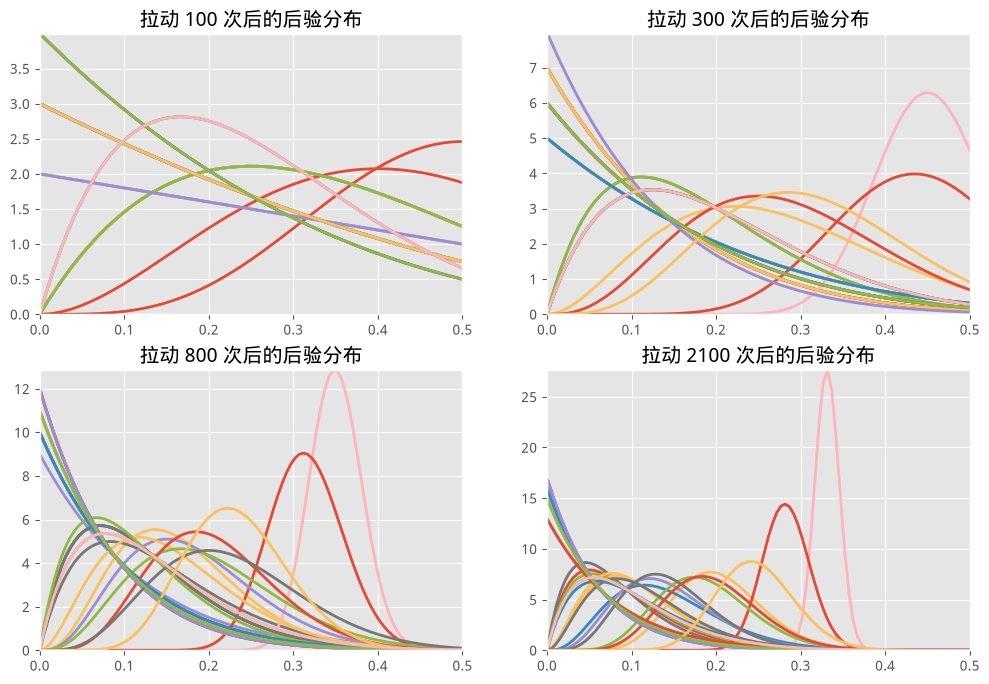

In [13]:

figsize(12.0, 8)
beta = stats.beta
hidden_prob = beta.rvs(1, 13, size=35)
print(hidden_prob)
bandits = Bandits(hidden_prob)
bayesian_strat = BayesianStrategy(bandits)

for j, i in enumerate([100, 200, 500, 1300]):
    plt.subplot(2, 2, j + 1)
    bayesian_strat.sample_bandits(i)
    plot_priors(bayesian_strat, hidden_prob, lw=2, alpha=0.0, plt_vlines=False)
    # plt.legend()
    plt.xlim(0, 0.5)



## 征询专家先验

指定一个主观先验,是从业者把问题的领域知识注入数学框架的方式。允许领域知识的介入,有许多好处:

- 加快 MCMC 收敛速度。举例来说,如果我们知道未知参数严格为正,就可以把注意力限制在这个范围内,从而节省本来会花在探索负值上的时间。
- 更精确的推断。通过给真实未知值附近赋予更高的权重,我们能收窄最终的推断结果(让后验更紧地围绕在未知量周围)。
- 更好地表达我们的不确定性。参见第五章的 *Price is Right* 问题。

除此之外还有很多其他理由。当然,贝叶斯方法的从业者并不是每个领域的专家,所以我们必须求助于领域专家来构建先验。不过在征询这些先验时,我们必须格外小心。有几点值得注意:

1. 根据经验,我会避免向非贝叶斯背景的从业者引入 Beta、Gamma 之类的概念。此外,非统计学背景的人经常会被"连续概率密度函数的取值怎么会超过 1"这个点绊倒。

2. 人们常常会忽略罕见的*尾部事件*,把过多的权重堆在分布均值附近。

3. 与上一点相关的是,几乎所有人都会低估自己猜测中的不确定性。

向非技术背景的专家征询先验尤其困难。与其引入可能会吓到专家的概率分布、先验这些概念,不如用一种简单得多的解决方案。

### 轮盘赌试验法

*轮盘赌试验法*(trial roulette method)[8] 的做法是,让专家在他认为可能出现的结果上放置筹码(想象成赌场筹码),以此来构建先验分布。专家会拿到 $N$ 个筹码(比如 $N=20$),被要求把它们放在一张预先印好的网格上,网格的每一格代表一个区间。每一列代表专家认为落在对应区间的概率有多大。每一枚筹码代表这个区间的概率增加 $\frac{1}{N} = 0.05$。举个例子 [9]:

> 一名学生被要求预测自己在未来一场考试中的分数。下图展示了一张填好的网格,用来征询主观概率分布。网格的横轴表示学生被要求考虑的可能区间(分数区间)。最上面一行的数字记录了每个区间对应的筹码数量。填好的网格(总共用了 20 枚筹码)显示,这名学生认为自己的分数有 30% 的概率落在 60 到 64.9 之间。

<img style="margin: auto" src="http://img641.imageshack.us/img641/4716/chipsbinscrisp.png" />

据此,我们就可以拟合出一个能刻画专家选择的分布。支持使用这种技巧的一些理由包括:

1. 关于专家主观概率分布形状的很多问题,不需要向专家提出一长串问题就能回答——统计学家只需要读出任意一点上下方的密度,或者任意两点之间的密度即可。

2. 在征询过程中,如果专家对自己最初的摆放方式不满意,可以随时挪动筹码——这样他们能对最终提交的结果更有把握。

3. 这种方式强制专家给出的一整套概率必须保持自洽。如果所有筹码都用完了,概率之和必须等于 1。

4. 图形化方法似乎能提供更准确的结果,尤其是对统计素养一般的参与者而言。



##### 示例: 股票收益率

各位股票经纪人请注意:你们的做法可能是错的。在选择该买哪支股票时,分析师通常会看这支股票的*日收益率*。设 $S_t$ 是股票在第 $t$ 天的价格,那么第 $t$ 天的日收益率是:

$$r_t = \frac{ S_t - S_{t-1} }{ S_{t-1} } $$

股票的*期望日收益率*记为 $\mu = E[ r_t ]$。显然,期望收益率高的股票更受欢迎。可惜的是,股票收益率里充斥着噪声,想要估计这个参数非常困难。而且,这个参数本身也可能随时间变化(想想 AAPL 股票的涨涨跌跌),所以用一份很长的历史数据集来估计并不明智。

历史上,期望收益率通常是用样本均值来估计的。这不是个好主意。前面提到过,小样本数据集的样本均值,有很大可能严重偏离真实值(详情同样参见第四章)。因此,贝叶斯推断才是这里正确的做法,因为它能在给出可能取值的同时,也呈现出我们的不确定性。

在这个练习中,我们会研究 AAPL、GOOG、TSLA 和 AMZN 的日收益率。在拉取数据之前,假设我们问了一位股票基金经理(一位金融专家,不过也可参见 [10]):

> 你觉得这几家公司各自的收益率大概长什么样?

我们这位股票经纪人,完全不需要懂正态分布、先验、方差这些术语,就能用上面的轮盘赌试验法构造出四个分布。假设它们看起来足够像正态分布,于是我们就用正态分布去拟合。它们大概长这样:


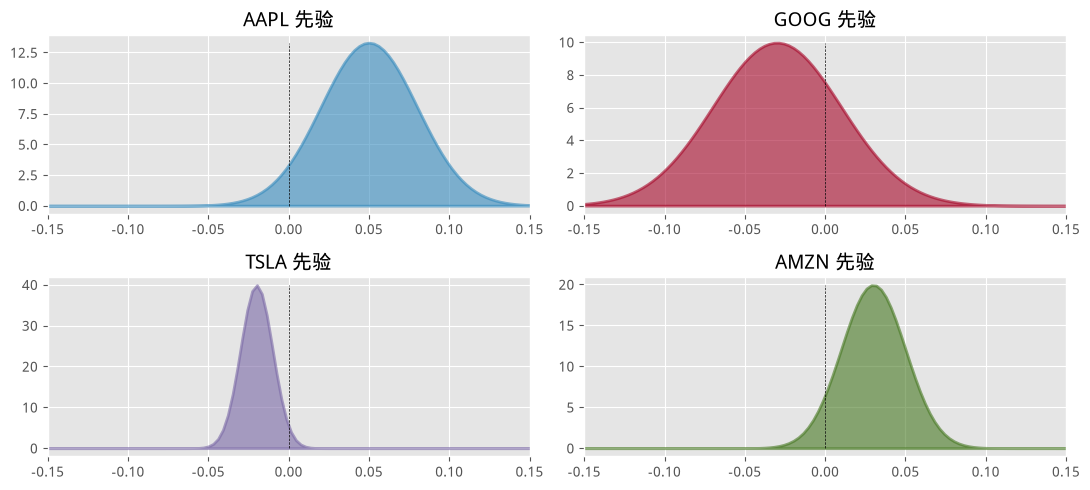

In [14]:

figsize(11., 5)
colors = ["#348ABD", "#A60628", "#7A68A6", "#467821"]

normal = stats.norm
x = np.linspace(-0.15, 0.15, 100)

expert_prior_params = {"AAPL": (0.05, 0.03),
                        "GOOG": (-0.03, 0.04),
                        "TSLA": (-0.02, 0.01),
                        "AMZN": (0.03, 0.02),
                        }

for i, (name, params) in enumerate(expert_prior_params.items()):
    plt.subplot(2, 2, i + 1)
    y = normal.pdf(x, params[0], scale=params[1])
    # plt.plot( x, y, c = colors[i] )
    plt.fill_between(x, 0, y, color=colors[i], linewidth=2,
                      edgecolor=colors[i], alpha=0.6)
    plt.title(name + " 先验")
    plt.vlines(0, 0, y.max(), "k", "--", linewidth=0.5)
    plt.xlim(-0.15, 0.15)
plt.tight_layout()



注意,这些都是主观先验:这位专家对每家公司的股票收益率都有自己的个人看法,并把这些看法表达成了一个分布。他并不是在痴心妄想——他是在注入领域知识。

为了更好地为这些收益率建模,我们应该研究收益率的*协方差矩阵*。举例来说,投资两支高度相关的股票并不明智,因为它们很可能会一起暴跌(这也是为什么基金经理会建议采用分散投资策略)。我们会用前面介绍过的 *Wishart 分布* 来处理这一点。



让我们获取这些股票的一些历史数据。我们会用收益率的协方差,作为 Wishart 随机变量的起始点。这并不是经验贝叶斯(后面会讲到区别),因为我们只是在决定一个起始点,而不是在影响参数本身。

**本中文·现代 PyMC 版说明**:如前所述,原书这里用 `pandas_datareader` 联网拉取雅虎财经的历史行情。我们把它换成了 `stock_returns_offline_data.py`——一份统计结构相仿(各股票波动率不同、股票之间存在温和的相关性)、但数值清楚标注为合成的离线数据,这样整个例子依然可以离线跑通。


In [15]:

import datetime
import collections
import pandas as pd
from stock_returns_offline_data import load_stock_returns

n_observations = 100  # 我们只截取最近 100 个交易日。

stocks = ["AAPL", "GOOG", "TSLA", "AMZN"]

enddate = "2015-04-27"
startdate = "2012-09-01"

stock_returns_full = load_stock_returns(stocks, startdate=startdate, enddate=enddate)
stock_returns = stock_returns_full[-n_observations:]

dates = stock_returns.index.to_list()



下面我们来搭建基本模型:


In [16]:

import pymc as pm
import pytensor.tensor as pt
from pytensor.tensor.nlinalg import matrix_inverse, matrix_dot
from pytensor.tensor.basic import diag
prior_mu = np.array([x[0] for x in expert_prior_params.values()])
prior_std = np.array([x[1] for x in expert_prior_params.values()])

init = stock_returns.cov()

with pm.Model() as model:
    cov_matrix = pm.WishartBartlett("covariance", np.diag(prior_std**2), 10, initval=init)

    mu = pm.Normal("returns", mu=prior_mu, sigma=1, shape=4)


Added new variable covariance_c to model diagonal of Wishart.


Added new variable covariance_z to model off-diagonals of Wishart.



下面是我们选定股票的收益率:


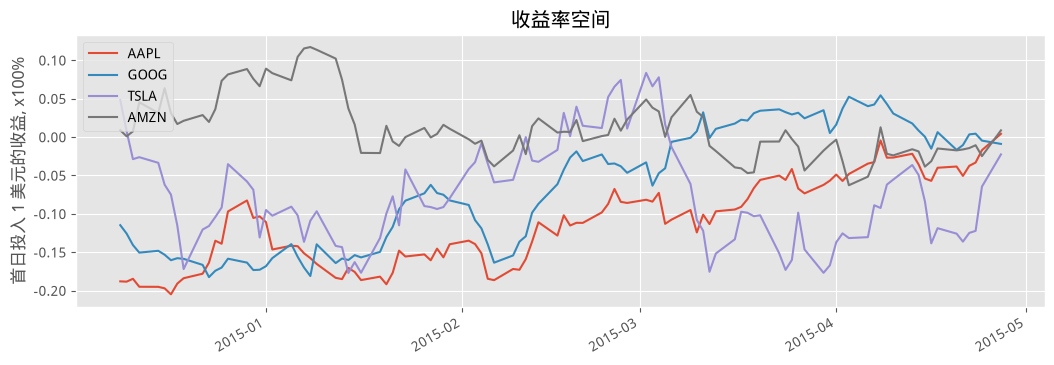

In [17]:

figsize(12.5, 4)

cum_returns = np.cumprod(1 + stock_returns) - 1
cum_returns.index = dates[::-1]
cum_returns.plot()

plt.legend(loc="upper left")
plt.title("收益率空间")
plt.ylabel("首日投入 1 美元的收益, x100%");


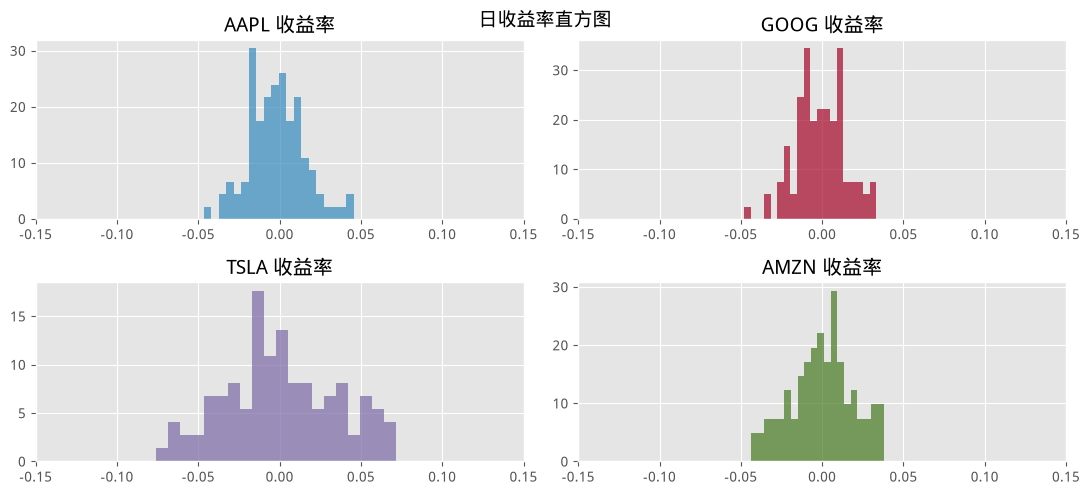

In [18]:

figsize(11., 5)

for i, _stock in enumerate(stocks):
    plt.subplot(2, 2, i + 1)
    plt.hist(stock_returns[_stock], bins=20,
             density=True, histtype="stepfilled",
             color=colors[i], alpha=0.7)
    plt.title(_stock + " 收益率")
    plt.xlim(-0.15, 0.15)

plt.tight_layout()
plt.suptitle("日收益率直方图", size=14);



下面我们对后验均值收益和后验协方差矩阵执行推断。


In [19]:

with model:
    obs = pm.MvNormal("observed returns", mu=mu, cov=cov_matrix, observed=stock_returns)
    # step = pm.NUTS()
    # 为了更快出结果, 这里用 chains=1
    trace = pm.sample(5000, tune=1000, chains=1)


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [covariance_c, covariance_z, returns]


Output()

Sampling 1 chain for 1_000 tune and 5_000 draw iterations (1_000 + 5_000 draws total) took 310 seconds.


Only one chain was sampled, this makes it impossible to run some convergence checks


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3194218/728918605.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.title("日收益率 $\mu$ 的后验分布")


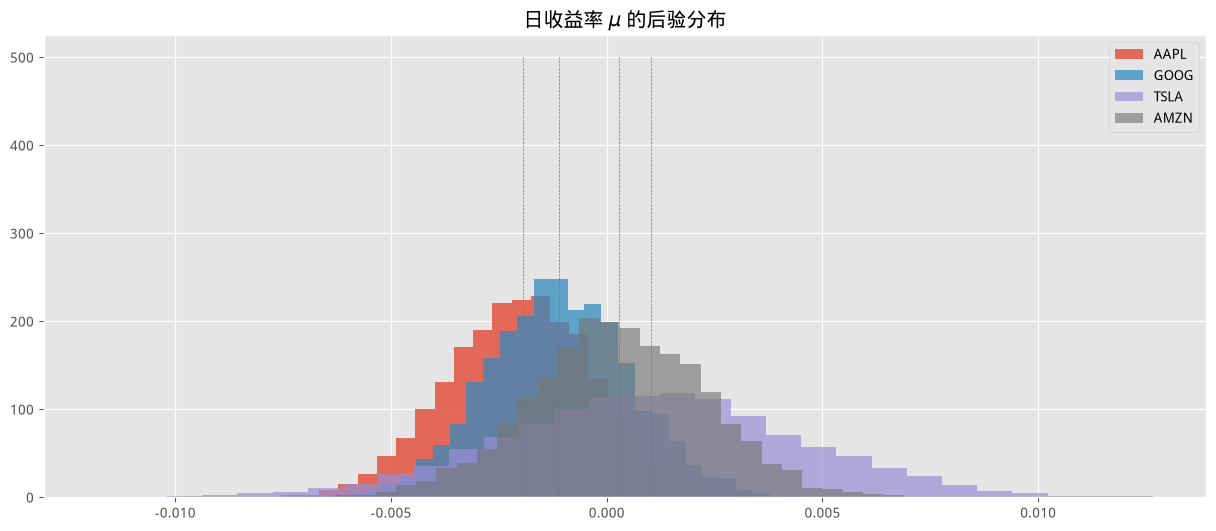

In [20]:

figsize(15, 6)

# 先看看均值收益率。
mu_samples = trace.posterior.returns.data[0]

for i in range(4):
    plt.hist(mu_samples[:, i], alpha=0.8 - 0.05 * i, bins=30,
             histtype="stepfilled", density=True,
             label="%s" % stock_returns.columns[i])

plt.vlines(mu_samples.mean(axis=0), 0, 500, linestyle="--", linewidth=.5)

plt.title("日收益率 $\mu$ 的后验分布")
plt.legend();



(这样的图正是本书封面的灵感来源。)

关于上面的结果,我们能说些什么呢?**提醒一下,本节使用的是合成的离线收益率数据,下面这段对具体公司走势的解读只是为了演示分析流程,并不反映任何真实市场信息。** 显然,在这份合成数据里 TSLA 表现较强,我们的分析认为它的日收益率接近 1%;类似地,AAPL 的大部分分布落在负值区间,暗示它的*真实日收益率*为负。

你可能没有立刻注意到,这些变量比我们给它们设置的先验要小一个数量级。举例来说,为了把它们放到和上面先验分布相同的尺度上比较:


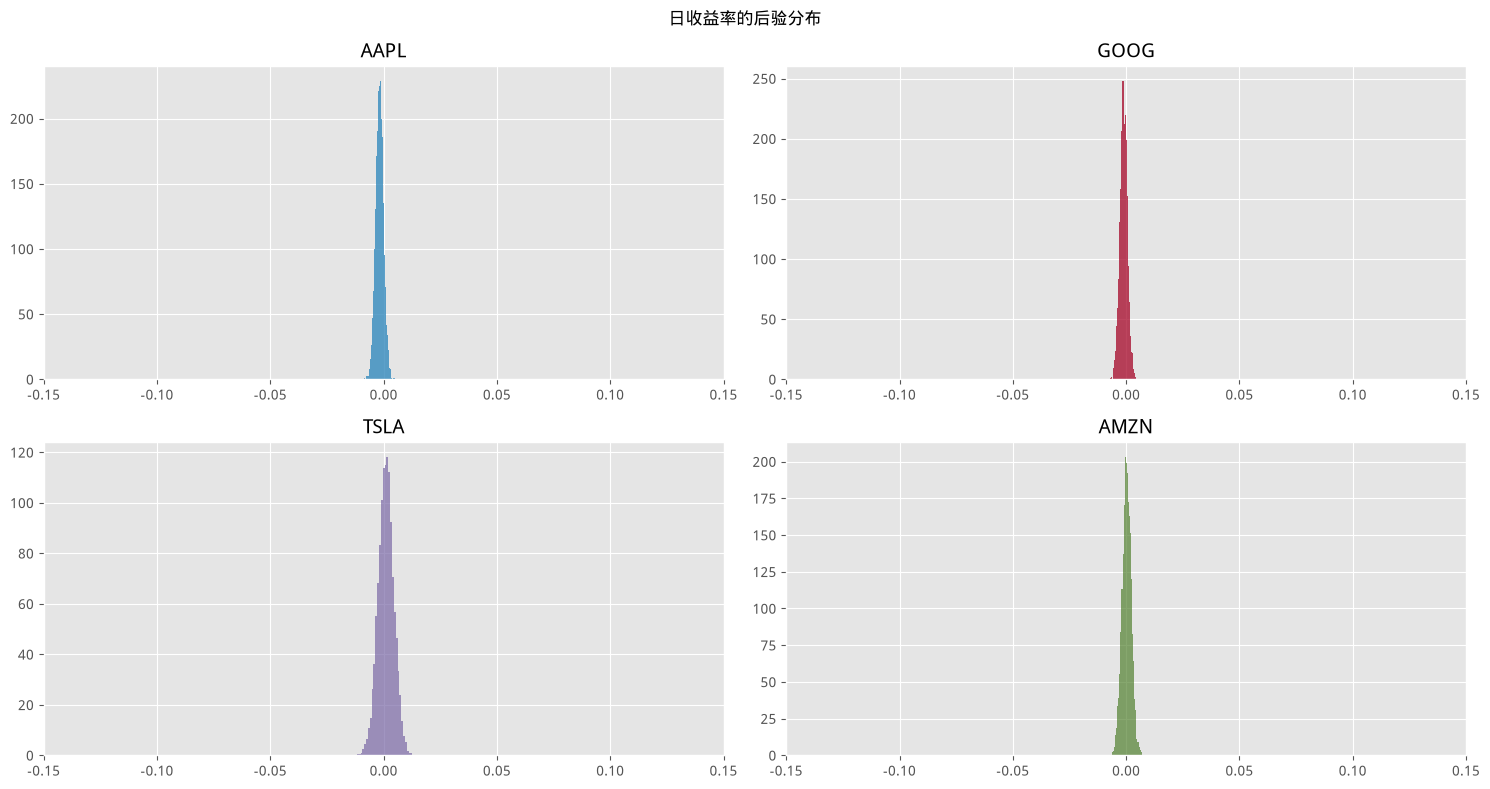

In [21]:

figsize(15.0, 8)
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.hist(mu_samples[:, i], alpha=0.8 - 0.05 * i, bins=30,
             histtype="stepfilled", density=True, color=colors[i],
             label="%s" % stock_returns.columns[i])
    plt.title("%s" % stock_returns.columns[i])
    plt.xlim(-0.15, 0.15)

plt.suptitle("日收益率的后验分布")
plt.tight_layout()



为什么会这样?回忆一下我提到过,金融领域的信噪比非常非常低。这意味着这是一个推断难度大得多的环境。对这些结果不应过度解读:注意(在第一幅图中)每个分布在 0 处都是正的,说明这支股票也有可能什么收益都没有。此外,主观先验也影响了结果。从基金经理的角度看,这是好事,因为它反映了他对这些股票更新后的信念;但从中立的角度看,这样的结果可能显得过于主观。

下面我们展示后验相关矩阵,以及后验标准差。有一点需要特别留意:Wishart 分布建模的是*协方差矩阵的逆*,所以我们必须先求逆才能得到协方差矩阵。我们还会对矩阵做归一化,得到*相关矩阵*。由于没法有效地画出成百上千个矩阵,我们退而求其次,通过展示*后验相关矩阵的均值*(在第 2 行定义)来概括相关矩阵的后验分布。


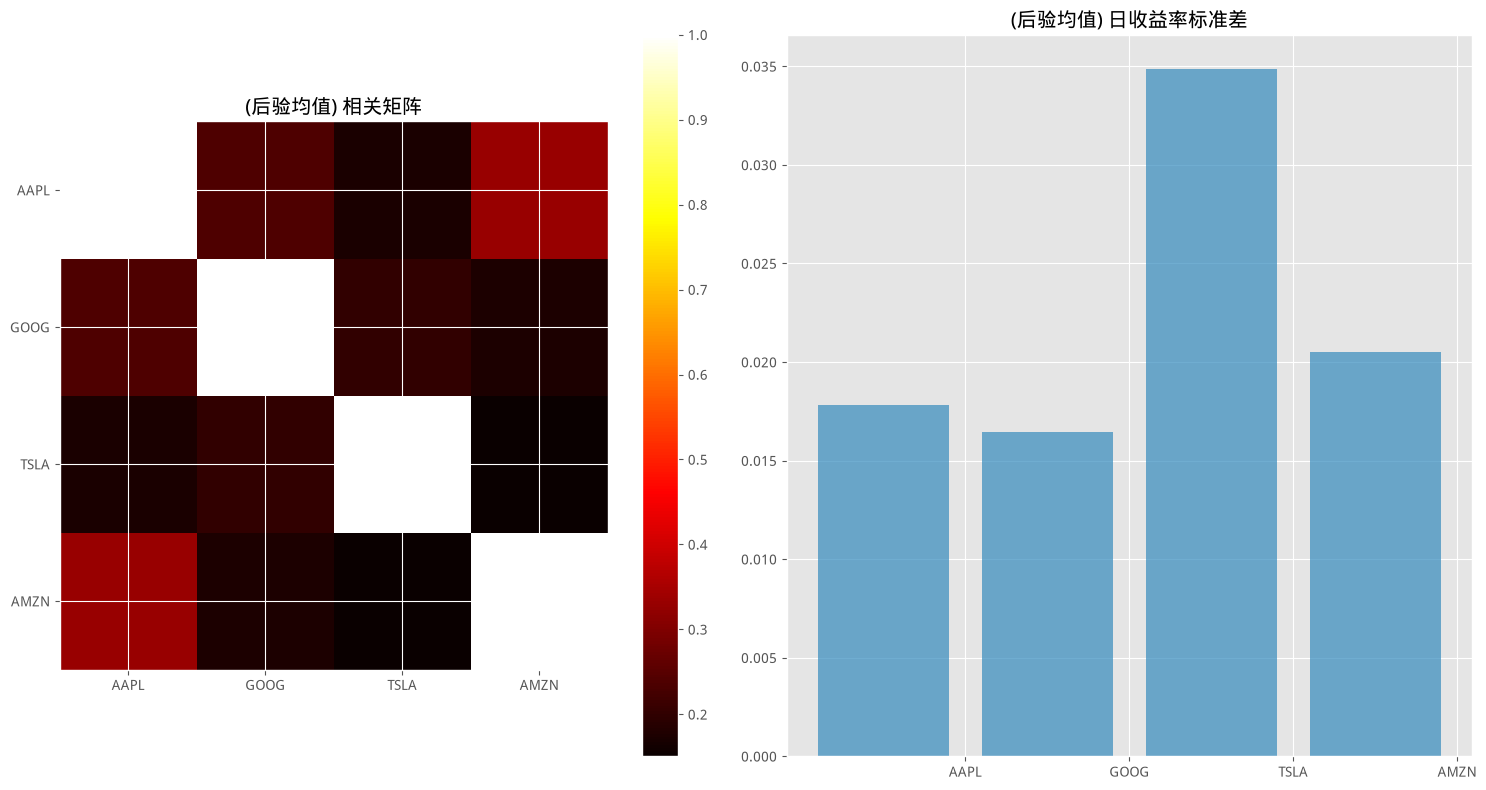

In [22]:

cov_samples = trace.posterior.covariance.data[0]
mean_covariance_matrix = cov_samples.mean(axis=0)

def cov2corr(A):
    '''
    协方差矩阵转换成相关矩阵。
    '''
    d = np.sqrt(A.diagonal())
    A = ((A.T / d).T) / d
    # A[ np.diag_indices(A.shape[0]) ] = np.ones( A.shape[0] )
    return A


plt.subplot(1, 2, 1)
plt.imshow(cov2corr(mean_covariance_matrix), interpolation="none",
           cmap="hot")
plt.xticks(np.arange(4), stock_returns.columns)
plt.yticks(np.arange(4), stock_returns.columns)
plt.colorbar(orientation="vertical")
plt.title("(后验均值) 相关矩阵")

plt.subplot(1, 2, 2)
plt.bar(np.arange(4), np.sqrt(np.diag(mean_covariance_matrix)),
        color="#348ABD", alpha=0.7)
plt.xticks(np.arange(4) + 0.5, stock_returns.columns);
plt.title("(后验均值) 日收益率标准差")

plt.tight_layout();



从上面的图可以看出,在这份合成数据中,TSLA 的波动率明显高于平均水平(结合收益率曲线来看这一点相当明显)。相关矩阵显示,各股票之间没有很强的相关性,不过 GOOG 和 AMZN 表现出相对更高一些的相关性(大约 0.30)——这正是我们在合成数据里预设的相关结构。

有了这份股票市场的贝叶斯分析结果,我们可以把它丢进一个均值-方差优化器里(我要再三强调,千万不要用频率学派的点估计来做这件事),求出最优解。这个优化器平衡了高收益和高方差之间的权衡取舍。

$$ w_{opt} = \max_{w} \frac{1}{N}\left( \sum_{i=0}^N \mu_i^T w - \frac{\lambda}{2}w^T\Sigma_i w \right)$$

其中 $\mu_i$ 和 $\Sigma_i$ 是第 $i$ 次后验估计的均值收益率和协方差矩阵。这是损失函数优化的又一个例子。



### Wishart 分布使用小贴士

如果你打算使用 Wishart 分布,不妨继续往下读;否则可以跳过这一节。

在上面的问题里,Wishart 分布的表现相当不错。可惜,这种情况并不常见。问题在于,估计一个 $N \times N$ 的协方差矩阵,涉及估计 $\frac{1}{2}N(N-1)$ 个未知量。即便 $N$ 不算很大,这也是一个相当庞大的数字。我个人曾尝试过用 $N=23$ 支股票做类似的模拟,最后发现自己相当于要求 MCMC 模拟额外估计至少 $\frac{1}{2}23 \times 22 = 253$ 个未知量(还不算问题里其他有意思的未知量)。这对 MCMC 来说并不容易。本质上,你是在要求 MCMC 遍历一个 250 多维的空间。而这个问题最初看起来还那么"人畜无害"!下面按重要程度列出一些建议:

1. 如果适用,就用共轭性。见下面的章节。

2. 使用一个好的起始值。什么样的起始值算好呢?数据的样本协方差矩阵就是!注意这并不是经验贝叶斯:我们没有触碰先验的参数,只是修改了 MCMC 的起始值。由于数值不稳定性,最好把样本协方差矩阵中的浮点数截断到几位精度(比如,数值不稳定可能导致矩阵不对称,这会让 PyMC 崩溃)。

3. 如果可能的话,尽量以先验的形式提供领域知识。我强调*如果可能*。要对每一个 $\frac{1}{2}N(N-1)$ 未知量都给出估计,大概率是不可能的。这种情况下,参见第 4 点。

4. 使用经验贝叶斯,也就是把样本协方差矩阵当作先验的参数。

5. 对 $N$ 非常大的问题,什么都帮不上忙。这时不妨问问自己:我真的关心*每一个*相关性吗?大概不会。再进一步问自己:我真的、真的很在意相关性吗?可能也不是。在金融领域,我们可以对自己最关心的东西设定一个非正式的优先级:首先是对 $\mu$ 的良好估计,其次是协方差矩阵对角线上的方差,最后才是相关性。所以,与其纠结于 $\frac{1}{2}(N-1)(N-2)$ 个相关性,不如把精力放在更重要的未知量上。

**还需要注意的一点**是,Wishart 分布的实现方式,从 PyMC 到 PyMC3 发生过变化。Wishart 分布对应的矩阵需要满足一些非常严格的数学性质。这使得 MCMC 方法几乎不可能提议出能被我们的采样过程接受的矩阵。在这里的模型中,我们采样的是 Wishart 分布矩阵的 Bartlett 分解,并用它来计算协方差矩阵的样本(http://en.wikipedia.org/wiki/Wishart_distribution#Bartlett_decomposition)。



## 共轭先验

回忆一下,Beta 先验搭配二项数据,会得到 Beta 后验。用图形表示:

$$ \underbrace{\text{Beta}}_{\text{先验}} \cdot \overbrace{\text{Binomial}}^{\text{数据}} = \overbrace{\text{Beta}}^{\text{后验} } $$

注意等式两边都有 $\text{Beta}$(不,你不能把它们约掉,这本来就不是一个*真正*的等式)。这是一个非常有用的性质。它让我们可以避免使用 MCMC,因为后验的解析形式是已知的,因此推断和分析都很容易推导。这个捷径正是上面贝叶斯老虎机算法的核心所在。幸运的是,还存在一整个具有类似性质的分布家族。

假设 $X$ 来自(或者被认为来自)某个知名的分布,记为 $f_\alpha$,其中 $\alpha$ 是 $f$ 可能未知的参数。$f$ 可以是正态分布、二项分布等等。对特定的分布族 $f_\alpha$,可能存在一个先验分布 $p_\beta$,使得:

$$ \overbrace{p_{\beta}}^{\text{先验}} \cdot \overbrace{f_{\alpha}(X)}^{\text{数据}} = \overbrace{p_{\beta'}}^{\text{后验} } $$

其中 $\beta'$ 是一组不同的参数,*但 $p$ 和先验是同一个分布族*。满足这种关系的先验 $p$ 被称为*共轭先验*(conjugate prior)。正如我提到的,共轭先验在计算上很有用,因为我们可以跳过基于 MCMC 的近似推断,直接得到后验。这听起来很棒,对吧?

可惜,并不完全是这样。共轭先验存在一些问题。

1. 共轭先验不是客观的。因此只有在确实需要主观先验时才有用。而且也不能保证共轭先验总能容纳从业者的主观意见。

2. 共轭先验通常只存在于简单的一维问题中。对于涉及更复杂结构的大型问题,基本没希望找到共轭先验。对于较小的模型,维基百科上有一张不错的[共轭先验表](http://en.wikipedia.org/wiki/Conjugate_prior#Table_of_conjugate_distributions)。

说实话,共轭先验的用处主要在于它们在数学上的便利性:从先验推到后验很简单。我个人认为,共轭先验只是一个巧妙的数学技巧,对手头的问题本身并没有提供太多洞见。



## Jeffreys 先验

前面我们提到过,客观先验很少是*真正*客观的。这句话部分想表达的意思是,我们希望先验不会给后验估计带来偏差。平先验看起来是个合理的选择,因为它对所有取值都分配相等的概率。

但平先验并不具备变换不变性(transformation invariant)。这是什么意思呢?假设我们有一个来自 Bernoulli($\theta$) 的随机变量 $\textbf X$。我们把先验定义为 $p(\theta) = 1$。


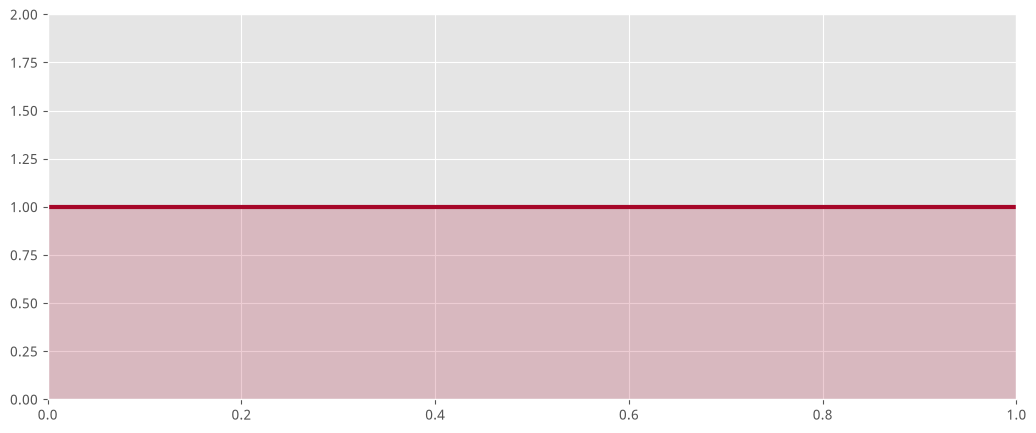

In [23]:

figsize(12.5, 5)

x = np.linspace(0.000, 1, 150)
y = np.linspace(1.0, 1.0, 150)
lines = plt.plot(x, y, color="#A60628", lw=3)
plt.fill_between(x, 0, y, alpha=0.2, color=lines[0].get_color())
plt.autoscale(tight=True)
plt.ylim(0, 2);



现在,让我们用函数 $\psi = \log \frac{\theta}{1-\theta}$ 对 $\theta$ 做一次变换。这只是一个把 $\theta$ 拉伸到整条实数轴上的函数。现在来看看,在这次变换下,$\psi$ 的不同取值各自的可能性如何。


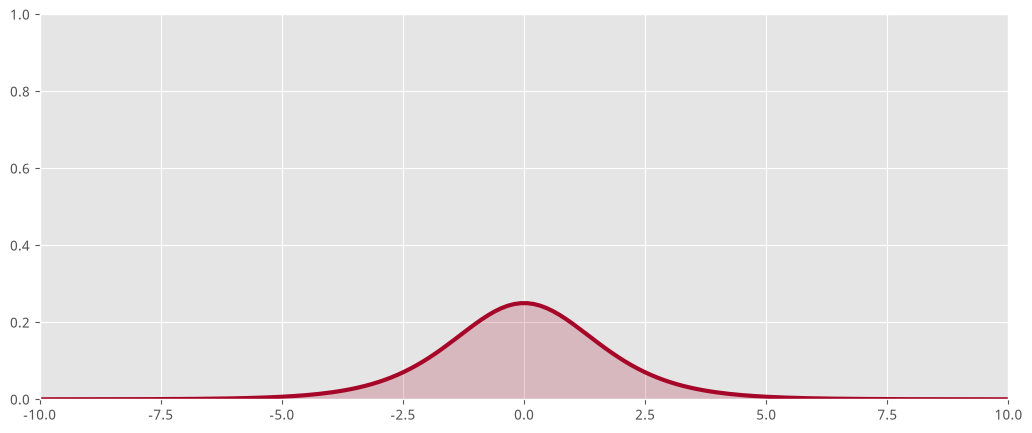

In [24]:

figsize(12.5, 5)

psi = np.linspace(-10, 10, 150)
y = np.exp(psi) / (1 + np.exp(psi)) ** 2
lines = plt.plot(psi, y, color="#A60628", lw=3)
plt.fill_between(psi, 0, y, alpha=0.2, color=lines[0].get_color())
plt.autoscale(tight=True)
plt.ylim(0, 1);



糟糕!我们的函数不再是平的了。原来平先验其实终究还是携带着信息的。Jeffreys 先验的意义,就是构造出这样一种先验:当你对最初设置先验的变量做变换时,它不会意外地变得带有信息性。

Jeffreys 先验定义为:

$$p_J(\theta) \propto \mathbf{I}(\theta)^\frac{1}{2}$$
$$\mathbf{I}(\theta) = - \mathbb{E}\bigg[\frac{d^2 \text{ log } p(X|\theta)}{d\theta^2}\bigg]$$

其中 $\mathbf{I}$ 是*费雪信息*(Fisher information)。



## 随着 $N$ 增大,先验的影响

在第一章里,我提到过,随着我们观测数据量的增加,先验的影响力会逐渐减弱。这很符合直觉。毕竟,我们的先验是基于此前已有的信息,而最终足够多的新信息会盖过此前信息的价值。先验被足够多的数据"淹没",其实也是件好事:如果我们的先验严重错误,数据的自我修正特性会让我们得到一个*不那么错*、并最终*正确*的后验。

我们可以从数学上看到这一点。首先,回忆一下第一章里把先验和后验联系起来的贝叶斯定理。下面这段引用来自 CrossValidated 网站上的一个问题:[样本量和先验对后验的影响力之间是什么关系?](http://stats.stackexchange.com/questions/30387/what-is-the-relationship-between-sample-size-and-the-influence-of-prior-on-poste) [1]

> 给定数据集 $\textbf X$,参数 $\theta$ 的后验分布可以写成

$$p(\theta | {\textbf X}) \propto \underbrace{p({\textbf X} | \theta)}_{{\textrm 似然}}  \cdot  \overbrace{ p(\theta) }^{ {\textrm 先验} }  $$

> 或者,更常见地写成对数尺度的形式:

$$ \log( p(\theta | {\textbf X})  ) = c + L(\theta;{\textbf X}) + \log(p(\theta)) $$

> 对数似然 $L(\theta;{\textbf X}) = \log \left( p({\textbf X}|\theta) \right)$ **会随样本量增大而增大**,因为它是数据的函数;而先验密度则不会。因此,随着样本量增加,$L(\theta;{\textbf X})$ 的绝对值会越来越大,而 $\log(p(\theta))$(对固定的 $\theta$ 取值)保持不变,于是 $L(\theta;{\textbf X}) + \log(p(\theta))$ 这个和,会随着样本量增加而越来越受 $L(\theta;{\textbf X})$ 主导。

这里有一个不太明显的有趣推论。随着样本量增大,所选定的先验的影响力会变小。因此,只要先验非零概率所覆盖的区域是相同的,无论选择哪种先验,推断最终都会收敛到同一个结果。

下面我们把这一点可视化出来。我们考察一个二项分布参数 $\theta$ 的两个后验的收敛过程,一个用平先验,另一个用偏向 0 的先验。随着样本量增大,这两个后验、以及由此得到的推断结果,会逐渐收敛。


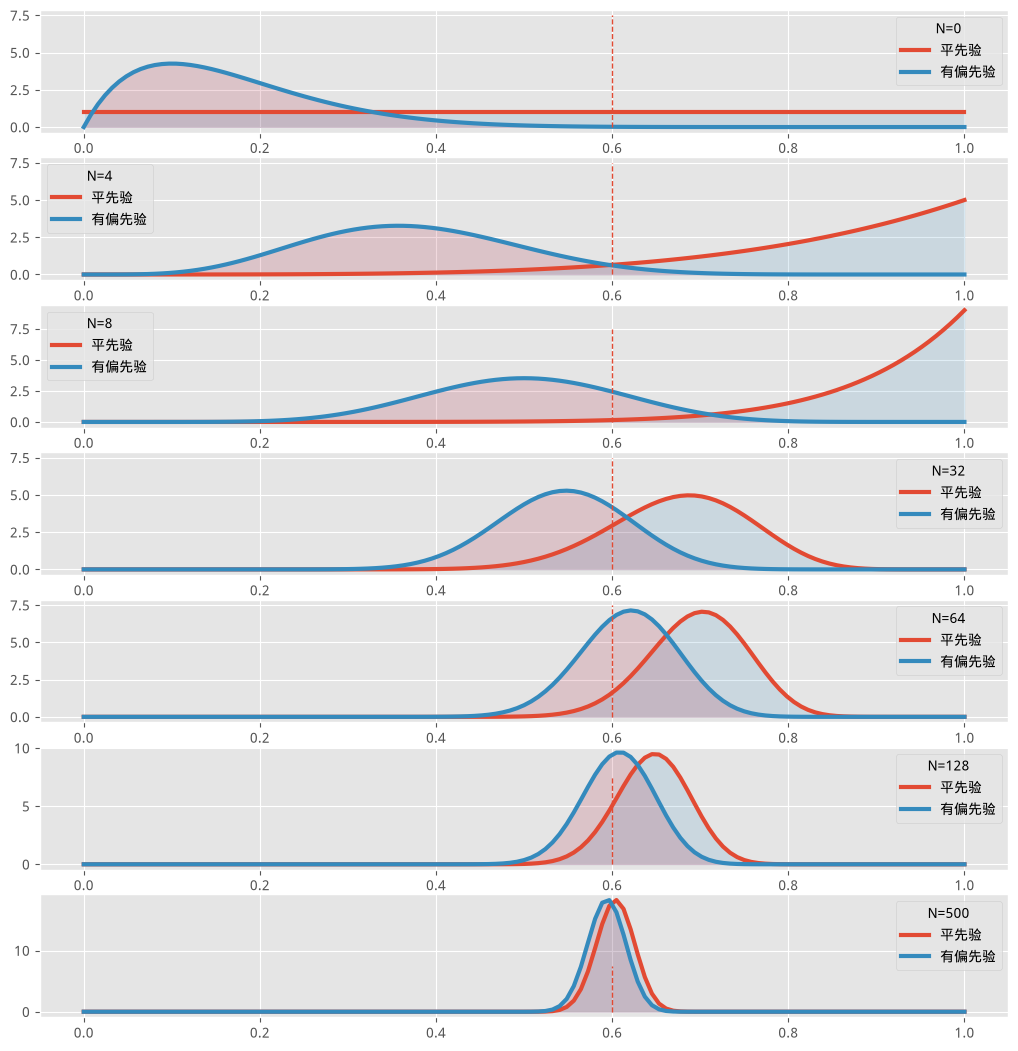

In [25]:

figsize(12.5, 15)

p = 0.6
beta1_params = np.array([1., 1.])
beta2_params = np.array([2, 10])
beta = stats.beta

x = np.linspace(0.00, 1, 125)
data = stats.bernoulli.rvs(p, size=500)

plt.figure()
for i, N in enumerate([0, 4, 8, 32, 64, 128, 500]):
    s = data[:N].sum()
    plt.subplot(8, 1, i + 1)
    params1 = beta1_params + np.array([s, N - s])
    params2 = beta2_params + np.array([s, N - s])
    y1, y2 = beta.pdf(x, *params1), beta.pdf(x, *params2)
    plt.plot(x, y1, label=r"平先验", lw=3)
    plt.plot(x, y2, label="有偏先验", lw=3)
    plt.fill_between(x, 0, y1, color="#348ABD", alpha=0.15)
    plt.fill_between(x, 0, y2, color="#A60628", alpha=0.15)
    plt.legend(title="N=%d" % N)
    plt.vlines(p, 0.0, 7.5, linestyles="--", linewidth=1)
    # plt.ylim( 0, 10)#



请记住,不是所有后验都会这么快"忘记"先验。这个例子只是为了说明,先验*最终*总会被遗忘。随着数据不断累积,先验逐渐被"遗忘"的这个现象,也正是贝叶斯推断和频率学派推断最终会趋于一致的原因。



### 从贝叶斯视角看正则化线性回归

带惩罚项的最小二乘回归,和贝叶斯先验之间存在一种非常有趣的联系。带惩罚项的线性回归是如下形式的一个优化问题:

$$ \text{argmin}_{\beta} \;\; (Y - X\beta)^T(Y - X\beta)  + f(\beta)$$

其中 $f$ 是某个函数(通常是类似 $|| \cdot ||_p^p$ 这样的范数)。

我们先来描述最小二乘线性回归的概率论解释。记响应变量为 $Y$,特征保存在数据矩阵 $X$ 中。标准线性模型是:

\begin{equation}
Y = X\beta + \epsilon
\end{equation}

其中 $\epsilon \sim \text{Normal}( {\textbf 0}, \sigma{\textbf I })$。简单来说,观测到的 $Y$ 是 $X$ 的线性函数(系数为 $\beta$)加上某个噪声项。我们要求解的未知量是 $\beta$。我们会用到正态随机变量的下面这条性质:

$$ \mu' + \text{Normal}( \mu, \sigma ) \sim \text{Normal}( \mu' + \mu , \sigma ) $$

把上面的线性模型改写成:

\begin{align}
& Y = X\beta + \text{Normal}( {\textbf 0}, \sigma{\textbf I }) \\\\
& Y = \text{Normal}( X\beta , \sigma{\textbf I }) \\\\
\end{align}

用概率论的记号,记 $f_Y(y \; | \; \beta )$ 为 $Y$ 的概率分布,回忆一下正态随机变量的密度函数(参见[这里](http://en.wikipedia.org/wiki/Normal_distribution)):

$$ f_Y( Y \; |\; \beta, X) = L(\beta|\; X,Y)= \frac{1}{\sqrt{ 2\pi\sigma} } \exp \left( \frac{1}{2\sigma^2} (Y - X\beta)^T(Y - X\beta) \right) $$

这就是 $\beta$ 的似然函数。取对数:

$$ \ell(\beta) = K - c(Y - X\beta)^T(Y - X\beta) $$

其中 $K$ 和 $c>0$ 是常数。极大似然方法希望针对 $\beta$ 最大化这个式子:

$$\hat{ \beta } = \text{argmax}_{\beta} \;\; - (Y - X\beta)^T(Y - X\beta) $$

等价地,我们可以*最小化上式的负值*:

$$\hat{ \beta } = \text{argmin}_{\beta} \;\; (Y - X\beta)^T(Y - X\beta) $$

这正是我们熟悉的最小二乘线性回归方程。因此我们证明了,最小二乘的解,和假设正态噪声下的极大似然解是一致的。接下来我们将进一步展示,通过为 $\beta$ 选择合适的先验,可以得到带惩罚项的线性回归。

#### 带惩罚项的最小二乘

在上面的基础上,一旦有了似然函数,我们就可以给 $\beta$ 加上一个先验分布,推导出后验分布的方程:

$$P( \beta | Y, X ) = L(\beta|\;X,Y)p( \beta )$$

其中 $p(\beta)$ 是 $\beta$ 各元素的先验。有哪些有意思的先验呢?

1. 如果我们*不显式地*包含先验项,实际上就是隐含了一个无信息先验 $P( \beta ) \propto 1$,可以把它想象成在所有数值上均匀分布。

2. 如果我们有理由相信 $\beta$ 的各个元素都不会太大,可以*先验地*假设:

$$ \beta \sim \text{Normal}({\textbf 0 }, \lambda {\textbf I } ) $$

由此得到的 $\beta$ 后验密度函数*正比于*:

$$ \exp \left( \frac{1}{2\sigma^2} (Y - X\beta)^T(Y - X\beta) \right) \exp \left( \frac{1}{2\lambda^2} \beta^T\beta \right) $$

取对数, 再合并、重新定义常数, 我们得到:

$$ \ell(\beta) \propto K -  (Y - X\beta)^T(Y - X\beta) - \alpha \beta^T\beta  $$

于是我们得到了希望最大化的函数(回忆一下,能让后验分布最大化的点正是 MAP,即*最大后验*):

$$\hat{ \beta } = \text{argmax}_{\beta} \;\; -(Y - X\beta)^T(Y - X\beta) - \alpha \;\beta^T\beta $$

等价地,我们可以最小化上式的负值,并把 $\beta^T \beta = ||\beta||_2^2$ 代入重写:

$$\hat{ \beta } = \text{argmin}_{\beta} \;\; (Y - X\beta)^T(Y - X\beta) + \alpha \;||\beta||_2^2$$

上面这个式子正是岭回归(Ridge Regression)。由此可见,岭回归对应于"正态误差 + $\beta$ 上的正态先验"这个线性模型的 MAP。

3. 类似地,如果我们对 $\beta$ 假设一个*拉普拉斯*先验,即

$$ f_\beta( \beta) \propto \exp \left(- \lambda ||\beta||_1 \right)$$

按照和上面同样的步骤,我们会得到:

$$\hat{ \beta } = \text{argmin}_{\beta} \;\; (Y - X\beta)^T(Y - X\beta) + \alpha \;||\beta||_1$$

这正是 LASSO 回归。关于这个等价关系有几点需要说明。LASSO 正则化带来的稀疏性,并不是因为先验给稀疏性本身分配了很高的概率。事实恰恰相反。真正产生 $\beta$ 稀疏性的,是 $|| \cdot ||_1$ 这个函数和使用 MAP 这两者结合的结果:[纯粹是一个几何论证](http://camdp.com/blogs/least-squares-regression-l1-penalty)。不过先验确实会带来系数整体向 0 收缩的效果。关于这一点,[2] 里有一段有意思的讨论。

关于贝叶斯线性回归的例子,可以参见第四章关于金融损失的那个例子。



##### 参考文献

1. Macro, . "What is the relationship between sample size and the influence of prior on posterior?." 13 Jun 2013. StackOverflow, Online Posting to Cross-Validated. Web. 25 Apr. 2013.

2. Starck, J.-L., , et al. "Sparsity and the Bayesian Perspective." Astronomy & Astrophysics. (2013).

3. Kuleshov, Volodymyr, and Doina Precup. "Algorithms for the multi-armed bandit problem." Journal of Machine Learning Research. (2000): 1-49.

4. Gelman, Andrew. "Prior distributions for variance parameters in hierarchical models." Bayesian Analysis. 1.3 (2006): 515-533.

5. Gelman, Andrew, and Cosma R. Shalizi. "Philosophy and the practice of Bayesian statistics." British Journal of Mathematical and Statistical Psychology. (2012).

6. http://jmlr.csail.mit.edu/proceedings/papers/v22/kaufmann12/kaufmann12.pdf

7. James, Neufeld. "Reddit's "best" comment scoring algorithm as a multi-armed bandit task." Simple ML Hacks. Blogger, 09 Apr 2013.

8. Oakley, J. E., Daneshkhah, A. and O'Hagan, A. Nonparametric elicitation using the roulette method. Submitted to Bayesian Analysis.

9. "Eliciting priors from experts." 19 Jul 2010. StackOverflow, Online Posting to Cross-Validated.

10. Taleb, Nassim Nicholas (2007), The Black Swan: The Impact of the Highly Improbable, Random House, ISBN 978-1400063512
